In [20]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping

In [21]:
import os

train_path = os.path.abspath("../dataset/train")
valid_path = os.path.abspath("../dataset/validation")

In [22]:
train_counts = {}
valid_counts = {}

for cls in os.listdir(train_path):
    train_counts[cls] = len(
        os.listdir(
            os.path.join(train_path, cls)
        )
    )

for cls in os.listdir(valid_path):
    valid_counts[cls] = len(
        os.listdir(
            os.path.join(valid_path, cls)
        )
    )

df_train = pd.DataFrame(
    train_counts.items(),
    columns=["Class","Train Images"]
)

df_valid = pd.DataFrame(
    valid_counts.items(),
    columns=["Class","Validation Images"]
)

dataset_summary = pd.merge(
    df_train,
    df_valid,
    on="Class"
)

dataset_summary["Total Images"] = (
    dataset_summary["Train Images"] +
    dataset_summary["Validation Images"]
)

dataset_summary

,Class,Train Images,Validation Images,Total Images
0,BrownSpot,400,123,523
1,Healthy,400,123,523
2,Hispa,400,123,523
3,LeafBlast,400,123,523


In [23]:
dataset_summary.to_csv(
    "../outputs/reports/dataset_summary.csv",
    index=False
)

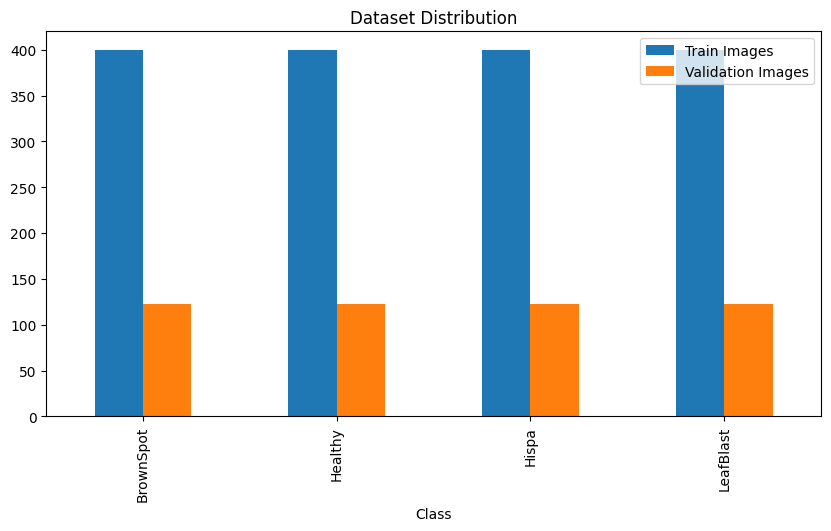

In [24]:
dataset_summary.plot(
    x="Class",
    y=["Train Images","Validation Images"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Dataset Distribution")

plt.savefig(
    "../outputs/figures/dataset_distribution.png"
)

plt.show()

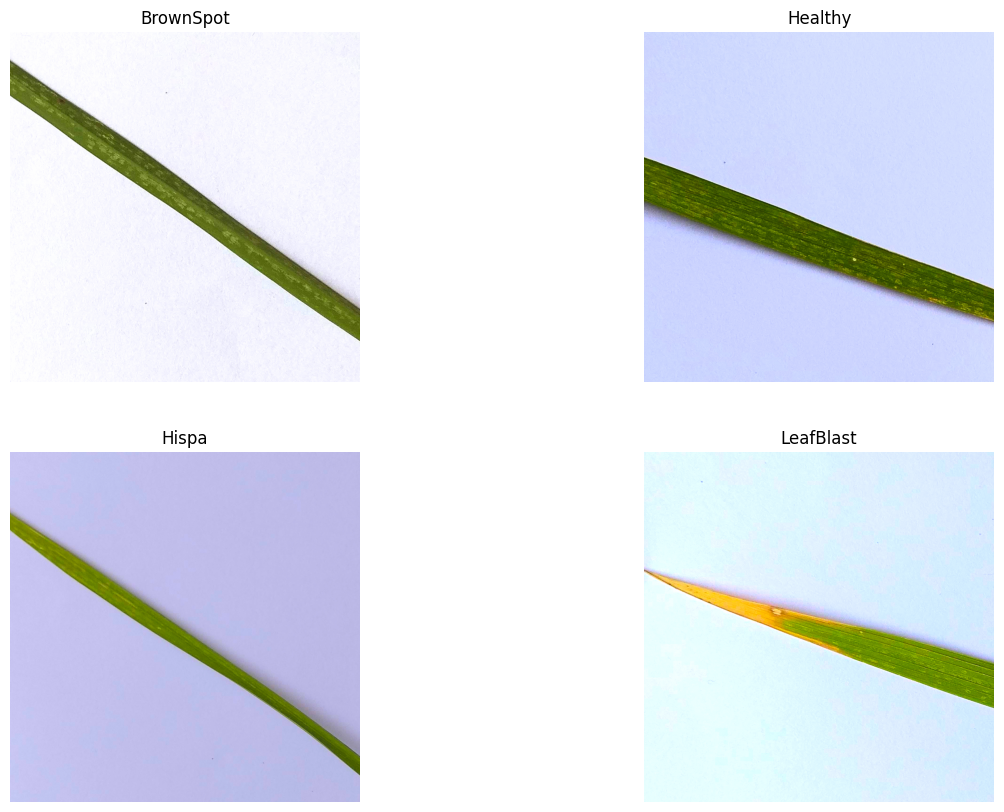

In [25]:
plt.figure(figsize=(15,10))

for i, cls in enumerate(os.listdir(train_path)):

    image_file = os.listdir(
        os.path.join(train_path, cls)
    )[0]

    image_path = os.path.join(
        train_path,
        cls,
        image_file
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.show()

In [62]:
# Dataset Loading and Generator Creation

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1600 images belonging to 4 classes.
Found 492 images belonging to 4 classes.
{'BrownSpot': 0, 'Healthy': 1, 'Hispa': 2, 'LeafBlast': 3}


In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

In [27]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

validation_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.
Found 492 images belonging to 4 classes.


In [28]:
cnn_model = Sequential([
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        4,
        activation='softmax'
    )
])

c:\Users\manik\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.2313 - loss: 1.6461 - val_accuracy: 0.2520 - val_loss: 1.3863
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.2338 - loss: 1.3867 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.2463 - loss: 1.3865 - val_accuracy: 0.2520 - val_loss: 1.3863
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.2569 - loss: 1.3875 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.2425 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 0.2344 - loss: 1.3864 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - accuracy: 0.2506 - loss: 1.3868 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - accuracy: 0.2262 - loss: 1.3868 - val_accuracy: 0.2500 - v

In [32]:
cnn_model.save(
    "../outputs/models/custom_cnn.keras"
)

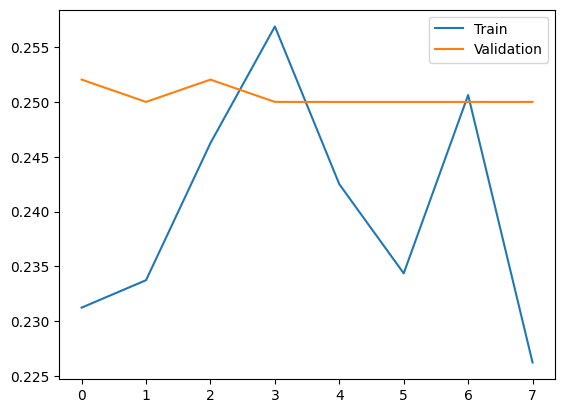

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.savefig(
    "../outputs/figures/accuracy_curve.png"
)

plt.show()

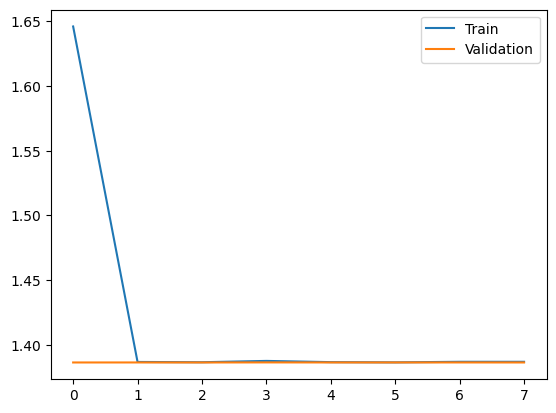

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.savefig(
    "../outputs/figures/loss_curve.png"
)

plt.show()

In [35]:
predictions = cnn_model.predict(
    validation_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = validation_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


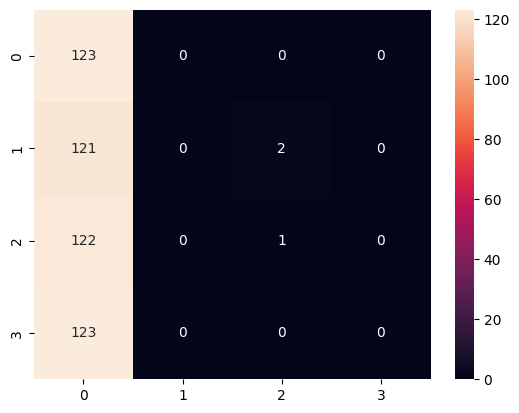

In [36]:
cm = confusion_matrix(
    y_true,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.savefig(
    "../outputs/figures/confusion_matrix.png"
)

plt.show()

In [37]:
report = classification_report(
    y_true,
    y_pred,
    target_names=list(
        train_generator.class_indices.keys()
    )
)

print(report)

              precision    recall  f1-score   support

   BrownSpot       0.25      1.00      0.40       123
     Healthy       0.00      0.00      0.00       123
       Hispa       0.33      0.01      0.02       123
   LeafBlast       0.00      0.00      0.00       123

    accuracy                           0.25       492
   macro avg       0.15      0.25      0.10       492
weighted avg       0.15      0.25      0.10       492



c:\Users\manik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\manik\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [38]:
with open(
    "../outputs/reports/classification_report.txt",
    "w"
) as f:
    f.write(report)

In [49]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

predictions = Dense(
    4,
    activation='softmax'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [50]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [51]:
mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 246s 5s/step - accuracy: 0.3731 - loss: 1.3326 - val_accuracy: 0.4431 - val_loss: 1.2305
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 239s 5s/step - accuracy: 0.4631 - loss: 1.1682 - val_accuracy: 0.4939 - val_loss: 1.1465
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.5131 - loss: 1.0951 - val_accuracy: 0.4898 - val_loss: 1.1536
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.5256 - loss: 1.0755 - val_accuracy: 0.5000 - val_loss: 1.1242
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.5269 - loss: 1.0813 - val_accuracy: 0.5325 - val_loss: 1.0910
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.5487 - loss: 1.0338 - val_accuracy: 0.5285 - val_loss: 1.0997
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 187s 4s/step - accuracy: 0.5663 - loss: 1.0201 - val_accuracy: 0.5386 - val_loss: 1.0731
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 365s 7s/step - accuracy: 0.5525 - loss: 1.0334 - val_accuracy: 0.5488 - v

In [54]:
mobilenet_model.save(
    r"C:\Rice-Leaf-Disease-Classification\outputs\models\mobilenetv2.keras"
)

In [58]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

predictions = Dense(
    4,
    activation='softmax'
)(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [59]:
efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
history_eff = efficientnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 278s 6s/step - accuracy: 0.2425 - loss: 1.4012 - val_accuracy: 0.2500 - val_loss: 1.4036
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - accuracy: 0.2475 - loss: 1.4105 - val_accuracy: 0.2500 - val_loss: 1.3888
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 230s 5s/step - accuracy: 0.2450 - loss: 1.3992 - val_accuracy: 0.2500 - val_loss: 1.3982
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 226s 5s/step - accuracy: 0.2688 - loss: 1.4061 - val_accuracy: 0.2500 - val_loss: 1.4080
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - accuracy: 0.2406 - loss: 1.3997 - val_accuracy: 0.2500 - val_loss: 1.3988
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 184s 4s/step - accuracy: 0.2338 - loss: 1.4129 - val_accuracy: 0.2500 - val_loss: 1.3895
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 193s 4s/step - accuracy: 0.2394 - loss: 1.3965 - val_accuracy: 0.2500 - val_loss: 1.3945
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.2500 - loss: 1.3945 - val_accuracy: 0.2500 - v

In [ ]:
efficientnet_model.save(
    "../outputs/models/efficientnetb0.keras"
)

In [ ]:
cnn_acc = max(history.history['val_accuracy'])

mobile_acc = max(
    mobilenet_history.history['val_accuracy']
)

efficient_acc = max(
    efficientnet_history.history['val_accuracy']
)

comparison_df = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "Validation Accuracy":[
        cnn_acc,
        mobile_acc,
        efficient_acc
    ]
})

comparison_df

In [ ]:
comparison_df.to_csv(
    "../outputs/reports/model_comparison.csv",
    index=False
)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3]
)

y_pred_prob = predictions

for i in range(4):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_pred_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} AUC={roc_auc:.2f}'
    )

plt.legend()

plt.savefig(
    "../outputs/figures/roc_curve.png"
)

plt.show()

In [ ]:
wrong_idx = np.where(
    y_true != y_pred
)[0]

error_analysis = []

for idx in wrong_idx:

    actual = list(
        train_generator.class_indices.keys()
    )[y_true[idx]]

    predicted = list(
        train_generator.class_indices.keys()
    )[y_pred[idx]]

    error_analysis.append(
        [actual,predicted]
    )

error_df = pd.DataFrame(
    error_analysis,
    columns=[
        "Actual",
        "Predicted"
    ]
)

error_df.head()

In [ ]:
error_df.to_csv(
    "../outputs/reports/error_analysis.csv",
    index=False
)

In [63]:
def make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name,
    pred_index=None
):

    grad_model = tf.keras.models.Model(
        [
            model.inputs
        ],
        [
            model.get_layer(
                last_conv_layer_name
            ).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array
        )

        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[
            :,
            pred_index
        ]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(
        heatmap
    )

    heatmap = tf.maximum(
        heatmap,
        0
    ) / tf.math.reduce_max(
        heatmap
    )

    return heatmap.numpy()

In [64]:
correct_idx = np.where(
    y_true == y_pred
)[0]

print(
    "Correct Predictions:",
    len(correct_idx)
)

Correct Predictions: 124


In [66]:
sample_idx = correct_idx[0]

img_batch = validation_generator[
    sample_idx
][0]

img = img_batch[0]

img_array = np.expand_dims(
    img,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name
)

NameError: name 'last_conv_layer_name' is not defined

In [ ]:
heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = (
    heatmap * 0.4 +
    img * 255
)

plt.figure(figsize=(8,8))

plt.imshow(
    superimposed_img.astype("uint8")
)

plt.title(
    "Grad-CAM Correct Prediction"
)

plt.axis("off")

plt.savefig(
    "../outputs/figures/gradcam_correct.png"
)

plt.show()

In [ ]:
wrong_idx = np.where(
    y_true != y_pred
)[0]

print(
    "Wrong Predictions:",
    len(wrong_idx)
)

In [ ]:
sample_idx = wrong_idx[0]

In [ ]:
img_batch = validation_generator[
    sample_idx
][0]

img = img_batch[0]

img_array = np.expand_dims(
    img,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name
)

In [ ]:
plt.savefig(
    "../outputs/figures/gradcam_false_positive.png"
)

In [ ]:
sample_idx = wrong_idx[1]

In [ ]:
class_names = list(
    train_generator.class_indices.keys()
)

print(
    "Actual:",
    class_names[y_true[sample_idx]]
)

print(
    "Predicted:",
    class_names[y_pred[sample_idx]]
)